In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 29.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 523kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 10.3MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.1MB/s]


In [3]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


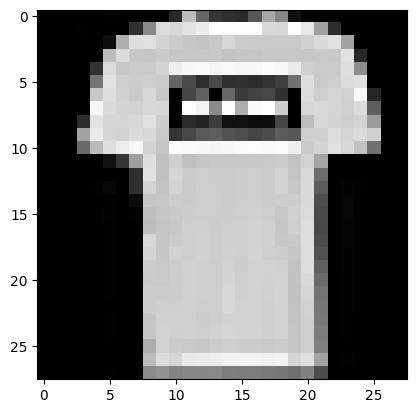

In [8]:
import matplotlib.pyplot as plt

def show_data(data):
  plt.imshow(data[0][0].squeeze(), cmap="gray")
  plt.show()

show_data(training_data[1])

In [15]:
training_data[1][1]

0

In [22]:
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cpu"
print(f"Using {device} device")

Using cpu device


In [23]:
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [24]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=10, bias=True)
  )
)


In [25]:
# count the number of parameters in the model

print(sum(p.numel() for p in model.parameters()))

7850


In [26]:
(1 - 0.0879) * 1e-3

0.0009121

In [39]:
out = model(training_data[0][0])
out

tensor([[-3.1090, -4.1951, -1.3724, -2.5203, -0.5967,  3.3685, -1.4212,  1.5984,
          2.4524,  5.5881]], grad_fn=<AddmmBackward0>)

In [28]:
torch.max(torch.softmax(model(training_data[1][0]), dim=-1), dim=-1)

torch.return_types.max(
values=tensor([0.1896], grad_fn=<MaxBackward0>),
indices=tensor([4]))

In [29]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [30]:
loss_fn(torch.tensor([[ 20, 0,  0,  0, 0, 0,  0, 0,
         0, 0]], dtype=torch.float32), torch.tensor([0]))

tensor(0.)

In [31]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [32]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [35]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.877344  [   64/60000]
loss: 0.947659  [ 6464/60000]
loss: 0.717155  [12864/60000]
loss: 0.965088  [19264/60000]
loss: 0.808584  [25664/60000]
loss: 0.825167  [32064/60000]
loss: 0.872061  [38464/60000]
loss: 0.827020  [44864/60000]
loss: 0.900919  [51264/60000]
loss: 0.814931  [57664/60000]
Test Error: 
 Accuracy: 73.3%, Avg loss: 0.824836 

Epoch 2
-------------------------------
loss: 0.834166  [   64/60000]
loss: 0.911707  [ 6464/60000]
loss: 0.676965  [12864/60000]
loss: 0.934196  [19264/60000]
loss: 0.780530  [25664/60000]
loss: 0.795003  [32064/60000]
loss: 0.842182  [38464/60000]
loss: 0.800814  [44864/60000]
loss: 0.871930  [51264/60000]
loss: 0.789591  [57664/60000]
Test Error: 
 Accuracy: 74.3%, Avg loss: 0.796721 

Epoch 3
-------------------------------
loss: 0.800130  [   64/60000]
loss: 0.882562  [ 6464/60000]
loss: 0.645624  [12864/60000]
loss: 0.909405  [19264/60000]
loss: 0.758478  [25664/60000]
loss: 0.770796  [32064/600

In [36]:

test(train_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 77.3%, Avg loss: 0.722010 

